<img src="assets/ga-logo.png" style="float: left; margin: 20px; height: 55px">

# Agglomerative Clustering

---

### About
Understand and use agglomerative (hierarchical) clustering.

### Learning Objectives
- Describe the agglomerative clustering technique.
- Identify advantages and disadvantages of agglomerative clustering.
- Implement agglomerative clustering using `scikit-learn`.

### Notebook Guide
- Imports
- Load Data
- Agglomerative (Hierarchical) Clustering
- Conclusions and Takeaways

# Imports

In [1]:
%pip install -qqq numpy pandas scikit-learn matplotlib seaborn scipy

/home/halgoz/work/GA/dl/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn import metrics
from scipy.cluster.hierarchy import dendrogram

# Load data
---

In [4]:
names = [
    'area', 'perimeter', 'compactness',
    'kern_len', 'kern_width', 'asymmetry',
    'groove_width', 'variety'
]
seeds = pd.read_csv('data/seeds_dataset.txt', sep=r'\s+', names=names)
seeds.head()

,area,perimeter,compactness,kern_len,kern_width,asymmetry,groove_width,variety
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1


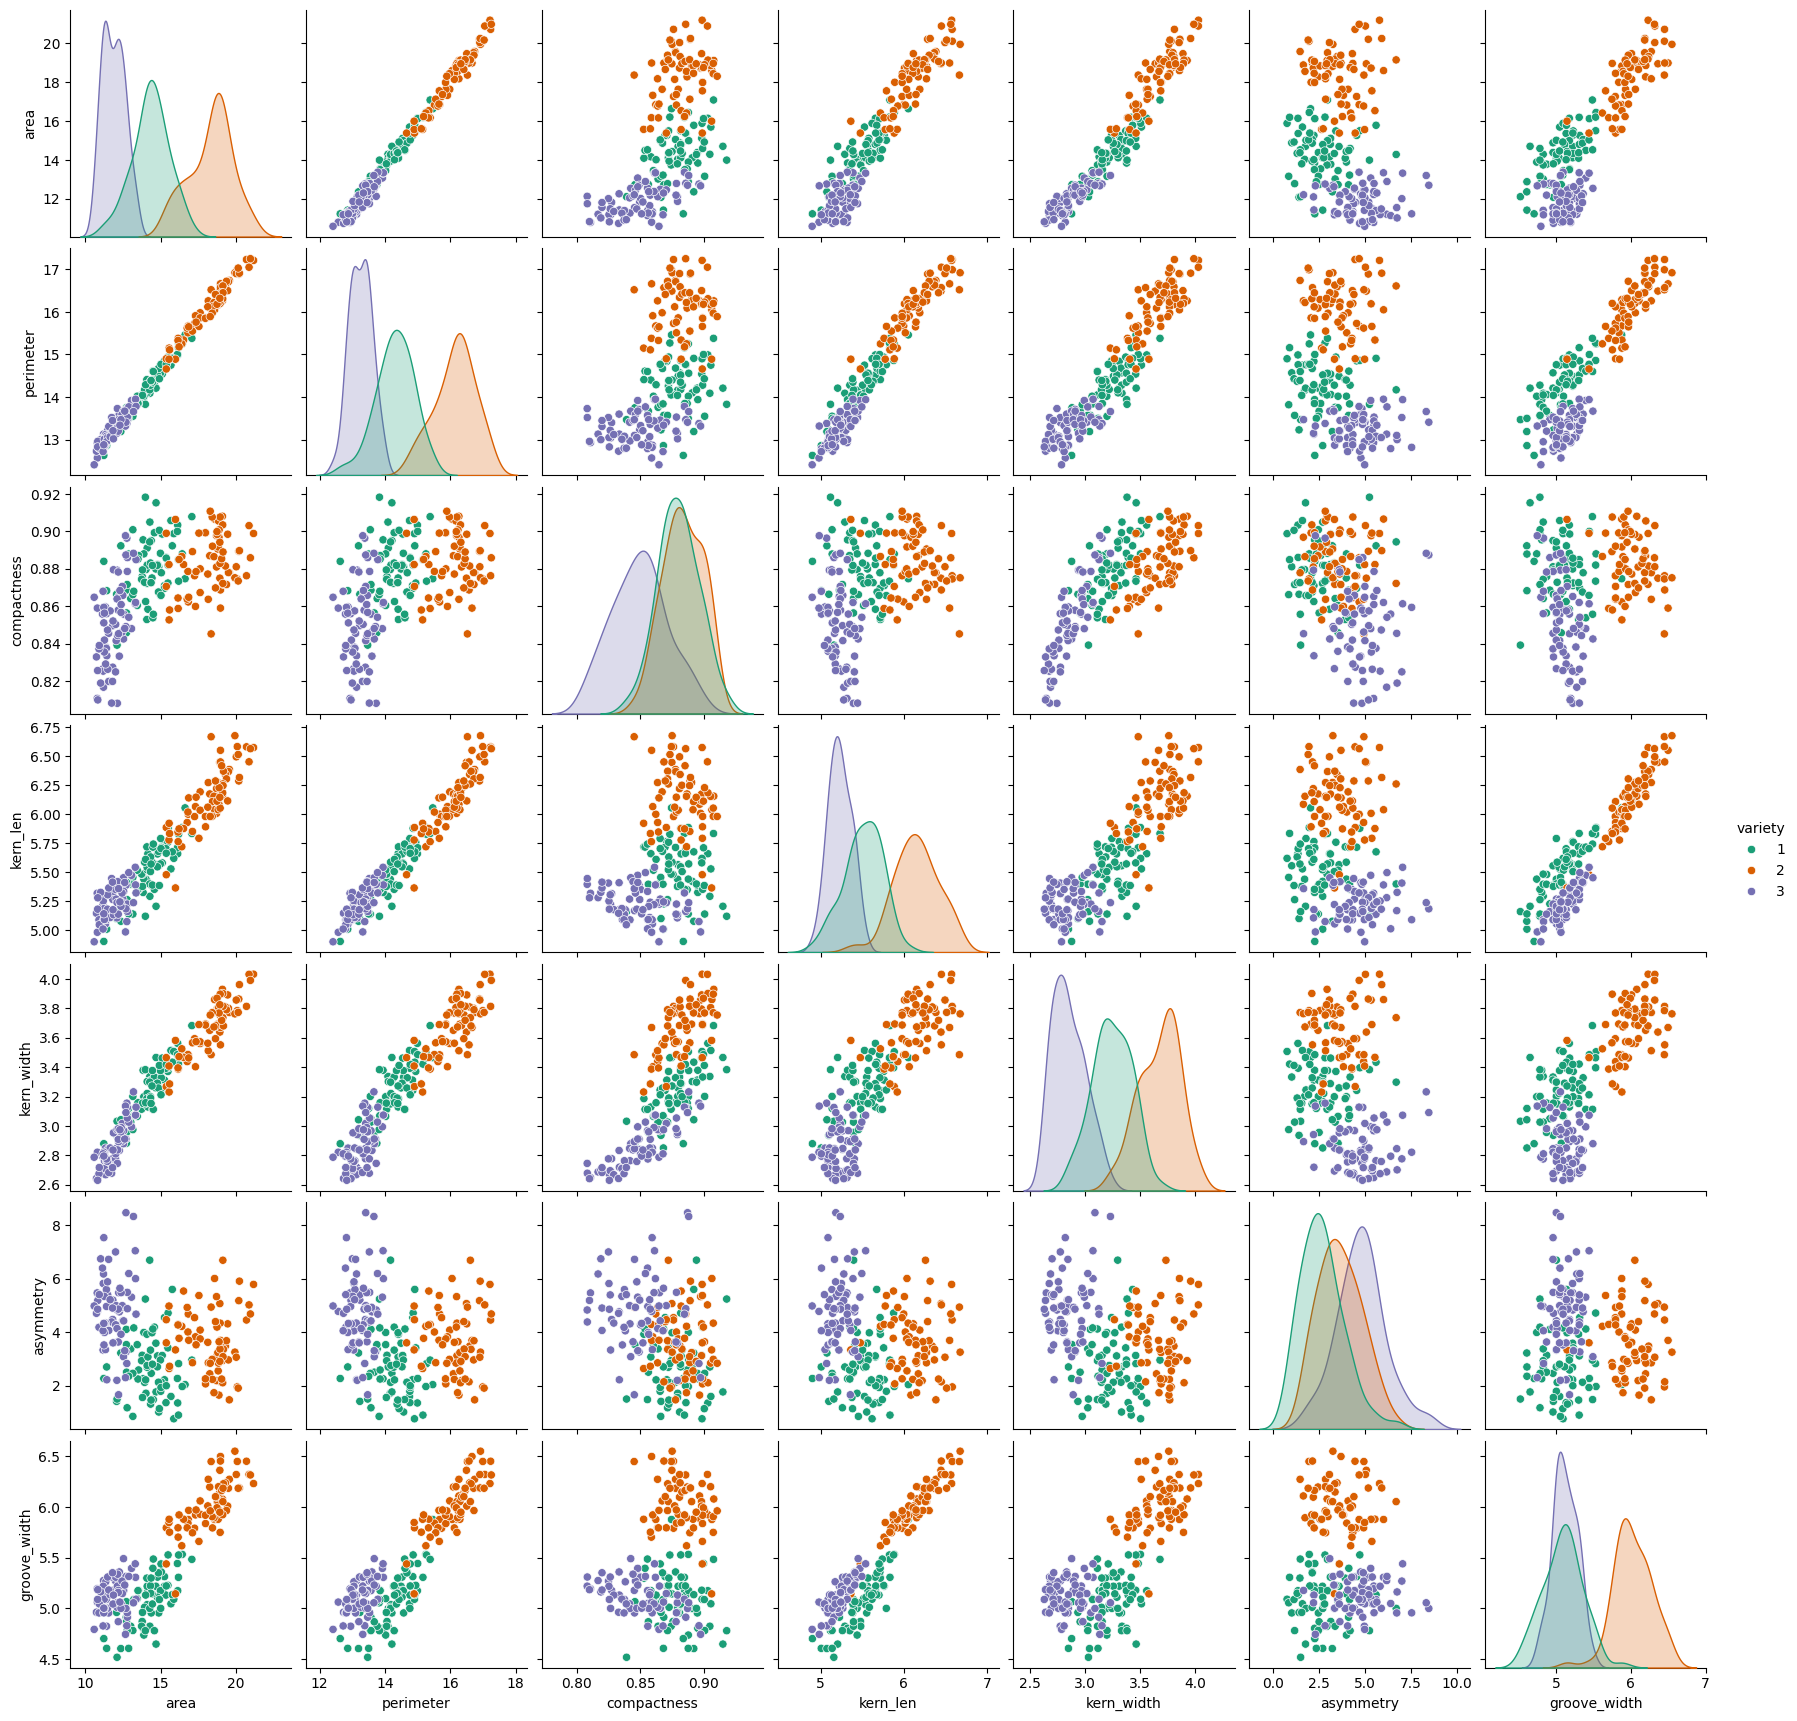

In [5]:
# Some fast EDA
sns.pairplot(seeds, hue='variety', palette='Dark2');

In [6]:
# Let's use ONLY kernel width and groove width to do our clustering.
# (YOU) make me an X and standard scale it!
X = seeds[['kern_width', 'groove_width']]
Z = StandardScaler().fit_transform(X)

# Agglomerative (Hierarchical) Clustering
---
**Hierarchical clustering** is a technique in which we join or split successive clusters. We can plot such a models' **dendrogram** if we want, too!

In [7]:
# Let's fit an agglomerative clusterer with 3 clusters.
agglom = AgglomerativeClustering(3)
agglom.fit(Z)

,"n_clusters n_clusters: int or None, default=2The number of clusters to find. It must be ``None`` if``distance_threshold`` is not ``None``.",3
,"metric metric: str or callable, default=""euclidean""Metric used to compute the linkage. Can be ""euclidean"", ""l1"", ""l2"",""manhattan"", ""cosine"", or ""precomputed"". If linkage is ""ward"", only""euclidean"" is accepted. If ""precomputed"", a distance matrix is neededas input for the fit method. If connectivity is None, linkage is""single"" and affinity is not ""precomputed"" any valid pairwise distancemetric can be assigned.For an example of agglomerative clustering with different metrics, see:ref:`sphx_glr_auto_examples_cluster_plot_agglomerative_clustering_metrics.py`... versionadded:: 1.2",'euclidean'
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the output of the computation of the tree.By default, no caching is done. If a string is given, it is thepath to the caching directory.",None
,"connectivity connectivity: array-like, sparse matrix, or callable, default=NoneConnectivity matrix. Defines for each sample the neighboringsamples following a given structure of the data.This can be a connectivity matrix itself or a callable that transformsthe data into a connectivity matrix, such as derived from`kneighbors_graph`. Default is ``None``, i.e, thehierarchical clustering algorithm is unstructured.For an example of connectivity matrix using:class:`~sklearn.neighbors.kneighbors_graph`, see:ref:`sphx_glr_auto_examples_cluster_plot_ward_structured_vs_unstructured.py`.",None
,"compute_full_tree compute_full_tree: 'auto' or bool, default='auto'Stop early the construction of the tree at ``n_clusters``. This isuseful to decrease computation time if the number of clusters is notsmall compared to the number of samples. This option is useful onlywhen specifying a connectivity matrix. Note also that when varying thenumber of clusters and using caching, it may be advantageous to computethe full tree. It must be ``True`` if ``distance_threshold`` is not``None``. By default `compute_full_tree` is ""auto"", which is equivalentto `True` when `distance_threshold` is not `None` or that `n_clusters`is inferior to the maximum between 100 or `0.02 * n_samples`.Otherwise, ""auto"" is equivalent to `False`.",'auto'
,"linkage linkage: {'ward', 'complete', 'average', 'single'}, default='ward'Which linkage criterion to use. The linkage criterion determines whichdistance to use between sets of observation. The algorithm will mergethe pairs of cluster that minimize this criterion.- 'ward' minimizes the variance of the clusters being merged.- 'average' uses the average of the distances of each observation of the two sets.- 'complete' or 'maximum' linkage uses the maximum distances between all observations of the two sets.- 'single' uses the minimum of the distances between all observations of the two sets... versionadded:: 0.20 Added the 'single' optionFor examples comparing different `linkage` criteria, see:ref:`sphx_glr_auto_examples_cluster_plot_linkage_comparison.py`.",'ward'
,"distance_threshold distance_threshold: float, default=NoneThe linkage distance threshold at or above which clusters will not bemerged. If not ``None``, ``n_clusters`` must be ``None`` and``compute_full_tree`` must be ``True``... versionadded:: 0.21",None
,"compute_distances compute_distances: bool, default=FalseComputes distances between clusters even if `distance_threshold` is notused. This can be used to make dendrogram visualization, but introducesa computational and memory overhead... versionadded:: 0.24For an example of dendrogram visualization, see:ref:`sphx_glr_auto_examples_cluster_plot_agglomerative_dendrogram.py`.",False


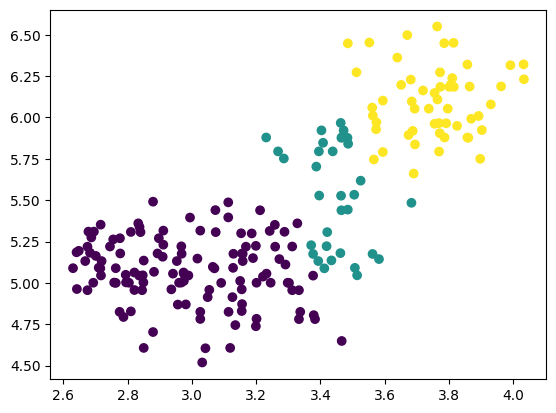

In [8]:
# Let's see it visually
plt.scatter(
    x=X.kern_width,
    y=X.groove_width,
    c=agglom.labels_
);

In [9]:
# Silhouette?
metrics.silhouette_score(Z, agglom.labels_)

0.4390897463455606

In [10]:
# TAKEN FROM SCIKIT-LEARN DOCS HERE!!
# https://scikit-learn.org/stable/auto_examples/cluster/plot_agglomerative_dendrogram.html

def plot_dendrogram(model, **kwargs):
    # Create linkage matrix and then plot the dendrogram

    # create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    # Plot the corresponding dendrogram
    dendrogram(linkage_matrix, **kwargs)

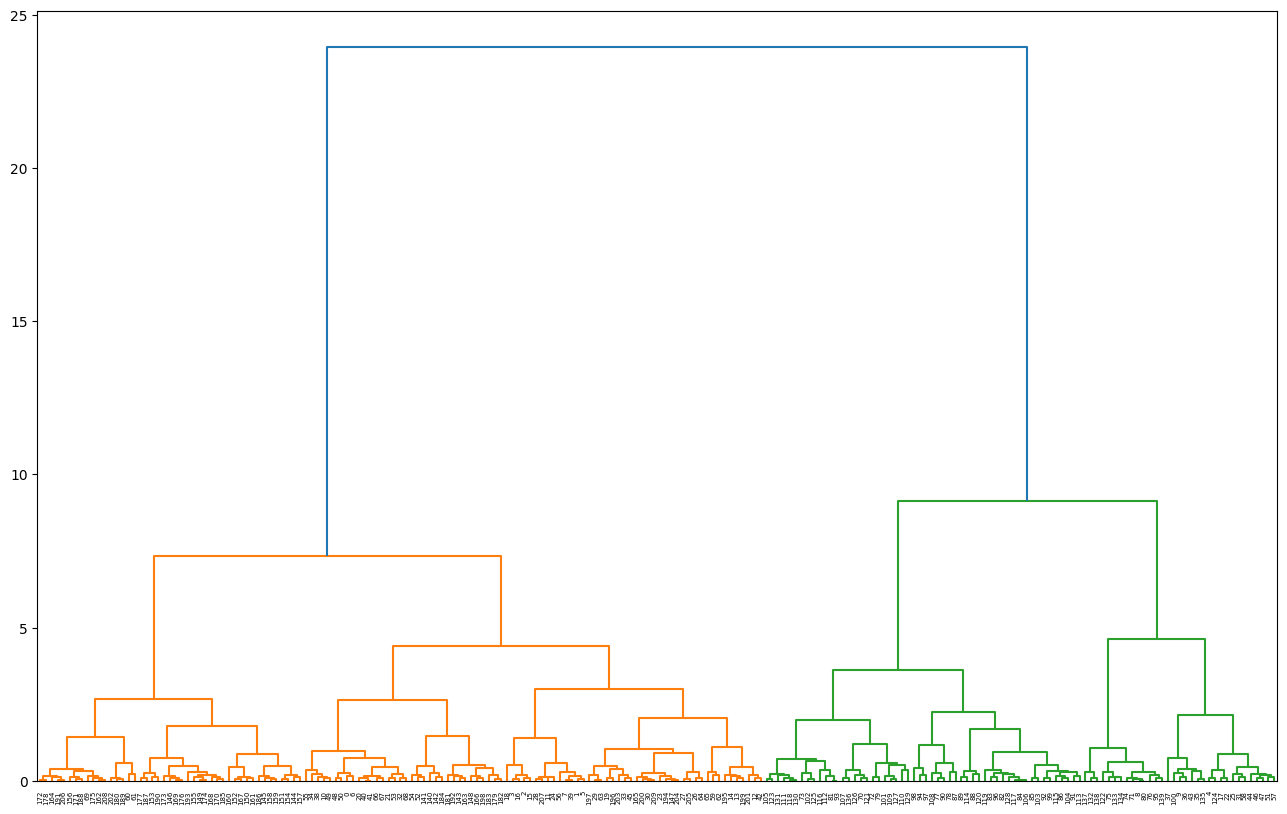

In [11]:
# These arguments are required to fit the whole tree. We can't plot the whole tree
# without computing it!
agglom = AgglomerativeClustering(n_clusters=None, distance_threshold=0)
agglom.fit(Z)

plt.figure(figsize=(16, 10))
plot_dendrogram(agglom)

## Agglomerative clustering conclusions
* Distance-based clustering algo that starts with every observation separate and successively joins clusters.
* Allows us to see the "path" of joins based similarity.
* Can plot nice **dendrograms**, although not always as useful as you'd think.